In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')


# Black-Scholes
def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        # Límite: precio intrínseco descontado
        if option == "call":
            return max(0.0, S - K*np.exp(-r*T))
        else:
            return max(0.0, K*np.exp(-r*T) - S)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option.lower() == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)  # en unidades de precio por 1.0 de sigma


def implied_vol(price_mkt, S, K, r, T, option="call", brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100):

    # Verificación de límites teóricos: el precio debe estar entre [intrínseco, cota superior]
    if option == "call":
        lower = max(0.0, S - K*np.exp(-r*T))
        upper = S
    else:
        lower = max(0.0, K*np.exp(-r*T) - S)
        upper = K*np.exp(-r*T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio de mercado fuera de rango teórico [{lower:.4f}, {upper:.4f}]")

    # Función objetivo
    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    fa, fb = f(a), f(b)

    # Ajusta el extremo superior si no cambia de signo (intenta ampliar)
    if fa*fb > 0:
        # intenta expandir b
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            fb = f(b_try)
            if fa*fb <= 0:
                b = b_try
                break

    # Intenta Brent
    try:
        iv = brentq(f, a, b, xtol=tol, maxiter=maxiter)
        return iv
    except Exception:
        pass

    # Si Brent falla, intenta método de Newton
    seed = min(max(sigma_hist if 'sigma_hist' in globals() and np.isfinite(sigma_hist) else 0.2, 1e-3), 2.0)
    try:
        iv = newton(lambda s: f(s), seed, fprime=lambda s: bs_vega(S, K, r, T, s), tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar una volatilidad implícita con los métodos intentados.")




In [2]:
ticker = 'SPY'

tk    = yf.Ticker(ticker)
exp = '2026-04-17'
today  = date.today()

data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']
S0 = float(data.iloc[-1])
r     = 0.042
K     = 680
T     = (date.fromisoformat(exp) - date.today()).days / 365

# solo informativo
daily_returns = data.pct_change().dropna()
sigma_hist = float(daily_returns.std() * np.sqrt(252))


# Precio mid: promedio de bid y ask, más estable que el último trade
chain    = tk.option_chain(exp).calls
row      = chain[chain['strike'] == K].iloc[0]
C_market = (row['bid'] + row['ask']) / 2

print(f"S0={S0:.2f} | bid={row['bid']:.2f} ask={row['ask']:.2f} mid={C_market:.4f}")
iv = implied_vol(C_market, S0, K, r, T, option="call")

bs_check = bs_price(S0, K, r, T, iv, option="call")
error    = abs(bs_check - C_market)

print(f"IV :        {iv:.4%}")
print(f"BS, C (IV): {bs_check:.6f}")
print(f"C_market     :{C_market:.6f}")

S0=661.43 | bid=5.48 ask=5.54 mid=5.5100
IV :        15.8491%
BS, C (IV): 5.510000
C_market     :5.510000


Puntos válidos: 903


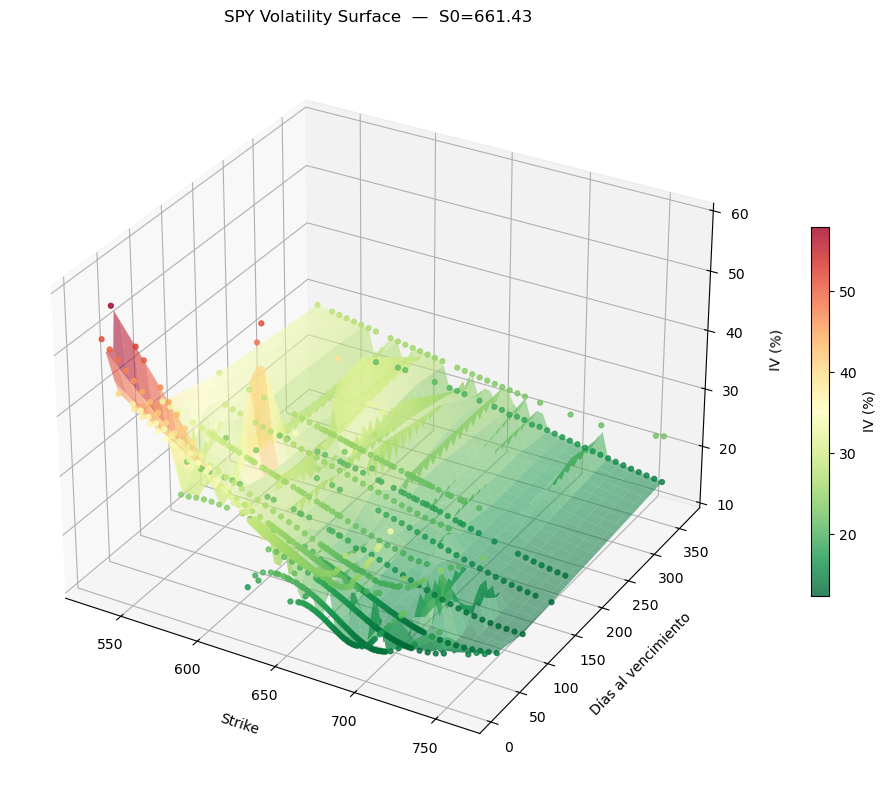

In [3]:

all_exps = [(e, (date.fromisoformat(e) - today).days)
            for e in tk.options
            if 7 <= (date.fromisoformat(e) - today).days <= 400]

# 8 vencimientos espaciados uniformemente entre 7 y 400 días
idx  = np.linspace(0, len(all_exps) - 1, min(8, len(all_exps)), dtype=int)
exps = [all_exps[i][0] for i in idx]

records = []

for exp in exps:
    T = (date.fromisoformat(exp) - today).days / 365

    # Calls y puts
    calls = tk.option_chain(exp).calls.copy()
    puts  = tk.option_chain(exp).puts.copy()

    for df, opt_type in [(calls, "call"), (puts, "put")]:
        # Filtros de liquidez y spread
        df = df[
            (df['bid'] > 0) &
            (df['ask'] > 0) &
            (df['volume'].fillna(0) > 5) &
            (df['ask'] / df['bid'] < 3.0) &
            (df['strike'] >= S0 * 0.80) &
            (df['strike'] <= S0 * 1.15)
        ].copy()
        df['mid'] = (df['bid'] + df['ask']) / 2

        for _, row in df.iterrows():
            K   = row['strike']
            mid = row['mid']
            try:
                iv = implied_vol(mid, S0, K, r, T, option=opt_type)
                if 0.05 <= iv <= 2.0:   # descarta IVs absurdas
                    records.append({
                        'expiry'  : exp,
                        'days'    : round(T * 365),
                        'K'       : K,
                        'moneyness': K / S0,
                        'type'    : opt_type,
                        'IV'      : iv * 100
                    })
            except Exception:
                pass

df_surf = pd.DataFrame(records)
print(f"Puntos válidos: {len(df_surf)}")

# Plot 3D
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_surf['K'],
    df_surf['days'],
    df_surf['IV'],
    c=df_surf['IV'],
    cmap='RdYlGn_r',
    s=12,
    alpha=0.8
)

# Superficie interpolada encima de los puntos
from scipy.interpolate import griddata

ki   = np.linspace(df_surf['K'].min(),    df_surf['K'].max(),    60)
ti   = np.linspace(df_surf['days'].min(), df_surf['days'].max(), 60)
KK, TT = np.meshgrid(ki, ti)
IV_grid = griddata(
    (df_surf['K'], df_surf['days']),
    df_surf['IV'],
    (KK, TT),
    method='linear'
)

ax.plot_surface(KK, TT, IV_grid, cmap='RdYlGn_r', alpha=0.55, linewidth=0)

ax.set_xlabel('Strike',              labelpad=10)
ax.set_ylabel('Días al vencimiento', labelpad=10)
ax.set_zlabel('IV (%)',              labelpad=10)
ax.set_title(f'{ticker} Volatility Surface  —  S0={S0:.2f}', pad=15)

fig.colorbar(scatter, ax=ax, shrink=0.5, label='IV (%)')
plt.tight_layout()
plt.show()


--- Tabla de Volatilidad Implícita (10 Strikes) ---
 Strike    Bid    Ask    Mid  IV (%)
  530.0 129.97 133.45 131.71   32.76
  590.0  71.76  74.84  73.30   27.81
  634.0  33.18  36.09  34.64   23.68
  648.0  22.86  25.27  24.06   21.98
  661.0  15.24  15.31  15.28   19.92
  673.0   8.56   8.63   8.60   17.87
  686.0   3.42   3.47   3.45   15.52
  699.0   0.91   0.95   0.93   13.65
  712.0   0.21   0.23   0.22   13.00
  725.0   0.07   0.09   0.08   13.63


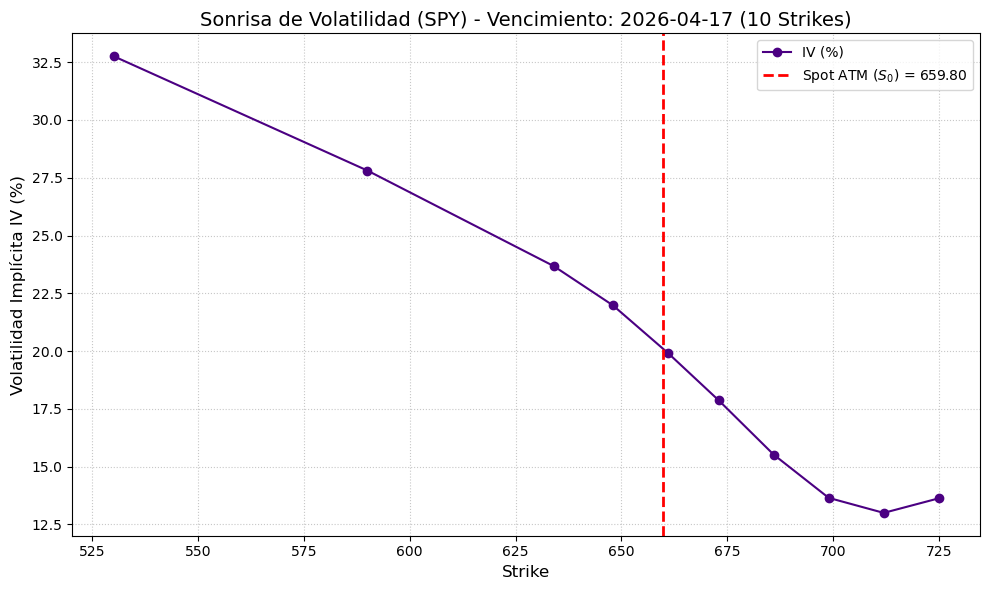

In [ ]:
ticker = 'SPY'
tk = yf.Ticker(ticker)
exp = '2026-04-17'
r = 0.042 

S0 = float(tk.history(period="1d")['Close'].iloc[-1])
T = (date.fromisoformat(exp) - date.today()).days / 365

chain = tk.option_chain(exp).calls

lower_bound = S0 * 0.80
upper_bound = S0 * 1.10
filtered_chain = chain[(chain['strike'] >= lower_bound) & (chain['strike'] <= upper_bound)].copy()

filtered_chain = filtered_chain.sort_values('strike')
if len(filtered_chain) > 10:
    indices_elegidos = np.linspace(0, len(filtered_chain) - 1, 10, dtype=int)
    filtered_chain = filtered_chain.iloc[indices_elegidos].copy()

resultados = []

for index, row in filtered_chain.iterrows():
    K = row['strike']
    bid = row['bid']
    ask = row['ask']
    
    if bid > 0 and ask > 0:
        mid = (bid + ask) / 2
        try:
            iv = implied_vol(mid, S0, K, r, T, option="call")
            resultados.append({
                'Strike': K,
                'Bid': round(bid, 2),
                'Ask': round(ask, 2),
                'Mid': round(mid, 2),
                'IV (%)': round(iv * 100, 2)
            })
        except Exception:
            pass

df_resultados = pd.DataFrame(resultados)

print("\n--- Tabla de Volatilidad Implícita (10 Strikes) ---")
print(df_resultados.to_string(index=False))

plt.figure(figsize=(10, 6))

plt.plot(df_resultados['Strike'], df_resultados['IV (%)'], marker='o', linestyle='-', color='indigo', label='IV (%)')
plt.axvline(x=S0, color='red', linestyle='--', linewidth=2, label=f'Spot ATM ($S_0$) = {S0:.2f}')

plt.title(f'Sonrisa de Volatilidad ({ticker}) - Vencimiento: {exp} (10 Strikes)', fontsize=14)
plt.xlabel('Strike', fontsize=12)
plt.ylabel('Volatilidad Implícita IV (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()

## Preguntas

#### ¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?

Es decreciente, esto implica que la volatilidad aumenta entra mas suba el precio por que las instituciones intentan cubrirse de una gran perdida en el precio del activo, no intentan cubrirse de una subida del precio y llega a una volatilidad implicita alrededor del 29% 

#### ¿En qué strike es mínima la IV? ¿Coincide con S0?

En el precio de 712 es del 13% la volatilidad implicita y no coincide con el precio strike (659.8)


#### ¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?

Un put de poder comprar la accion a un precio muy alto por si llega a tener una subida altisima el activo, por eso la colita del final que significa que si sube a 760 por ejemplo, la puedes comprar a 720 y venderla a 760 sacandole una ganancia de 40

#### ¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?

Que no puedes hacer una cobertura con una volatilidad homocedastica, o perderias muchisimo dinero, este supuesto del Black-Scholes es de los mas peligrosos 